In [3]:
from scipy.stats import bernoulli, binom
from matplotlib.pyplot import bar, show, hist, grid, legend, xticks

In [41]:
p = 0.5
bernoulli.rvs(p)

0

In [95]:
def random_walk(n,p):
    poz = 0
    poz_viz = []
    # poz_viz.append(poz)
    for _ in range(n):
        if(bernoulli.rvs(p)):
            poz += 1
        else:
            poz -= 1
        poz_viz.append(poz)
    return poz_viz

In [62]:
print(random_walk(7, 0.7));

[-1, 0, -1, 0, 1, 2, 3]


In [127]:
def thousand_walk(n, p):
    data = [ random_walk(n,p)[-1] for _ in range(1000)]
    bin_edges = [k + 0.5 for k in range(-n-1,n+1)]

    hist(data, bin_edges, density = True, rwidth = 0.9, color = 'magenta', edgecolor = 'black')
    distribution = dict([ (2*k - n, binom.pmf(k,n,p)) for k in range(n+1)])
    bar(distribution.keys(), distribution.values(), width = 0.85, color = 'orange', edgecolor = 'black',alpha= 0.6)
   
    xticks(range(-n, n+1))
    grid()
    show()

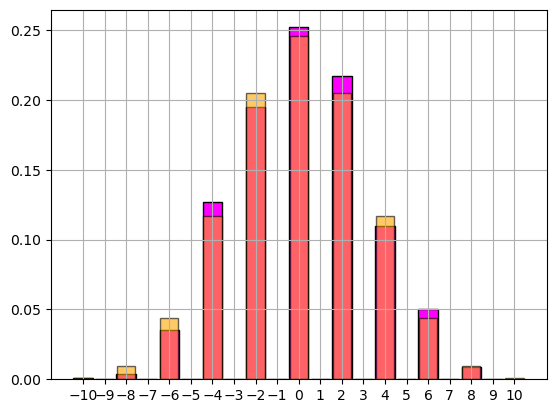

In [128]:
thousand_walk(10, 0.5)

In [222]:
def thousand_circle_walk(n,p, m):
    data = [ random_walk(n,p)[-1]%m for _ in range(1000)]
    bin_edges = [k + 0.5 for k in range(-1, m)]

    hist(data, bin_edges, density = True, rwidth = 0.9, color = 'magenta', edgecolor = 'black')
    distribution = dict([(k,0) for k in range(m)])
    for k in range(n+1):
        distribution[(2*k - n) %m] += binom.pmf(k,n,p)
    bar(distribution.keys(), distribution.values(), width = 0.85, color = 'orange', edgecolor = 'black',alpha= 0.6)
   
    xticks(range(0, m))
    grid()
    show()

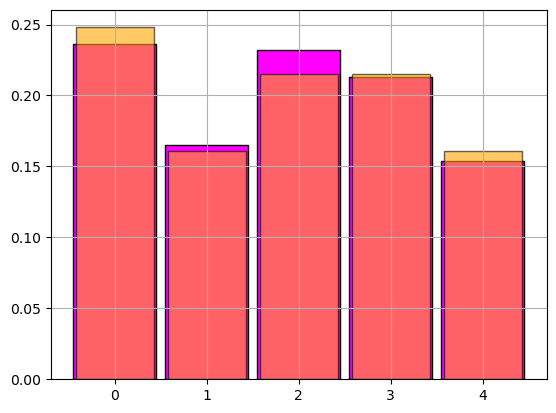

In [223]:
thousand_circle_walk(10,0.5, 5)

In [227]:
 from scipy.stats import hypergeom, geom

In [245]:
print(hypergeom.pmf(6,49,6,6))
print(hypergeom.pmf(3,49,6,6))

7.151123842018517e-08
0.017650403866870105


In [250]:
p = sum([hypergeom.pmf(k,49,6,6) for k in [3,4,5,6]])

In [263]:
data = geom.rvs(p, size=1000)
probabilitate_estimata = sum([x>=10 for x in data])/1000
probablilitate_teoretica = 1 - geom.cdf(9, p)

print(probabilitate_estimata, probablilitate_teoretica)

0.84 0.844238101245036
